In [2]:
# Apply bias adjustment to forecast
import xarray as xr
import numpy as np
import pandas as pd

In [4]:
ds_forecast = xr.open_zarr("./data/tas_forecast.zarr")
ds_bias = xr.open_zarr("./data/bias_adjustment_ERA5_19932016.zarr")

In [58]:
def apply_bias(fm):
    group = ds.where(ds.forecastMonth == fm, drop=True)
    return group.groupby("valid_time.month") - ds_bias.sel(forecastMonth=fm)


In [59]:
ds = ds_forecast['tas']
#forecast days to forecastMonth
ds = ds.assign_coords(
    forecastMonth=(["forecast_period"], ((ds.forecast_period.dt.days / 30) + 1).astype(int).data)
)
#swap valid_time and forecast_period
ds = ds.swap_dims({"forecast_period": "valid_time"})

results = [apply_bias(fm) for fm in ds_bias.forecastMonth.values]
forecast_corrected = xr.concat(results, dim="valid_time")
forecast_corrected = forecast_corrected.rename({"t2m": "tas"})

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/d

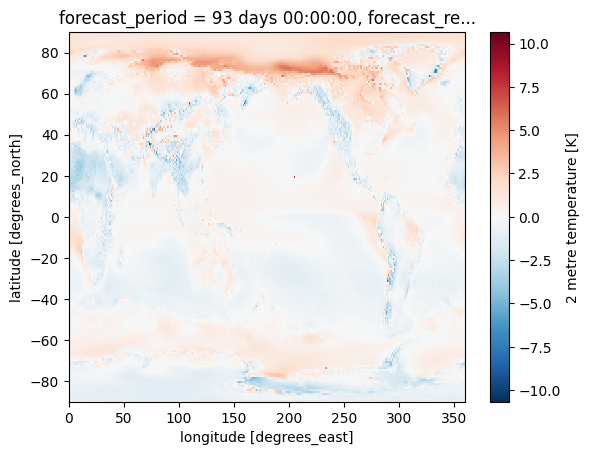

In [63]:
(ds_forecast['tas'].sel(number = 1).sel(valid_time = "2026-08-02")-forecast_corrected['tas'].sel(number = 1).sel(valid_time = "2026-08-02")).plot()